In [64]:
import plotly as px
import matplotlib.pyplot as plt
import os
import numpy as np 
import pandas as pd
import joblib
from sklearn.preprocessing import minmax_scale
from utils import find_peaks, find_period, moving_average, my_find_peaks_2
from gaitExtraction import gait_extraction
from gaitFeaturesExtraction import load_pose_data, cal_step_per_rounds
import cv2
import soundfile as sf

In [2]:
video_path = "/HDD3/leo/NTUH_PD/demo03.mp4"
#video_path = "/mnt/pd_app/results/test/test.mp4"
out_video_root = "/HDD3/leo/NTUH_PD/"
gait_extraction(video_path, out_video_root, save_out_video=True)


Initializing gait model...
load checkpoint from local path: /HDD3/leo/NTUH_PD/Parkinsons-Disease-Voice-Hand-Gait-Model-master/pdmodel/checkpoint/faster_rcnn_r50_fpn_1x_coco_20200130-047c8118.pth
load checkpoint from local path: /HDD3/leo/NTUH_PD/Parkinsons-Disease-Voice-Hand-Gait-Model-master/pdmodel/checkpoint/hrnet_w48_coco_wholebody_384x288_dark-f5726563_20200918.pth
[>>>>>>>>>>>>>>>>>>>>>>>>>>>>>] 912/912, 7.0 task/s, elapsed: 130s, ETA:     0s
Loading: /HDD3/leo/NTUH_PD/pose_results_demo03.npy
(1080, 1920)


/HDD3/leo/NTUH_PD/Parkinsons-Disease-Voice-Hand-Gait-Model-master/pdmodel/gaitExtraction.py:127: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  np.save(out_pose_path, np.array(pose_det_results_list))
/HDD3/leo/NTUH_PD/Parkinsons-Disease-Voice-Hand-Gait-Model-master/pdmodel/gaitExtraction.py:128: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  np.save(out_person_path, np.array(person_results_list))


Loading model ... 912
Generating 3D human pose ...
Saving 3D reconstruction...
Completing saving...


In [63]:
pose_2d_pth = "../../pose_results_demo03.npy"
pose_3d_pth = '../../3d_demo03.npz'

pose_2d, pose_3d = load_pose_data(pose_2d_pth, pose_3d_pth)

In [6]:

# Skeleton structure (parent indices for each keypoint)
skeleton = {
    'parents': [-1, 0, 0, 1, 2, 0, 0, 5, 6, 7, 8, 5, 6, 11, 12, 13, 14]
}

# Define a function to draw the pose with skeleton on an image
def draw_pose(image, keypoints, skeleton):
    for i, (x, y, v) in enumerate(keypoints):
        if v > 0:
            cv2.circle(image, (int(x), int(y)), 5, (0, 0, 255), -1)
            parent = skeleton['parents'][i]
            if parent != -1 and keypoints[parent, 2] > 0:
                cv2.line(image, (int(x), int(y)), (int(keypoints[parent, 0]), int(keypoints[parent, 1])), (255, 0, 0), 2)

# Open the input video
input_video_path = '../../demo03.mp4'  # Replace with your input video file path
cap = cv2.VideoCapture(input_video_path)

# Get video properties
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Open the output video
output_video_path = 'output.mp4'  # Replace with your output video file path
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

# Process each frame
for i in range(frame_count):
    ret, frame = cap.read()
    if not ret:
        break

    # Draw the pose on the current frame
    draw_pose(frame, pose_2d[i], skeleton)
    
    # Write the frame to the output video
    out.write(frame)

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()

print("Video processing completed. Saved as", output_video_path)


Video processing completed. Saved as output.mp4


/tmp/ipykernel_142531/1664252881.py:71: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(f"frames/frame_{i:04d}.png")
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1000, 700) to (1008, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved as animation.mp4


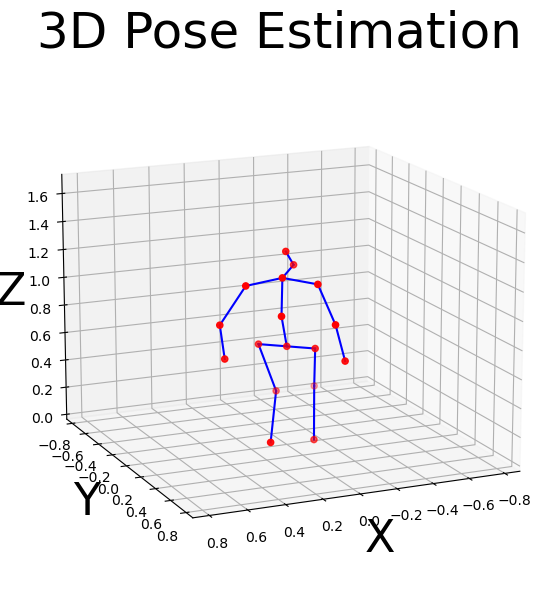

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
import imageio
import os

# Skeleton structure
skeleton = {
    'parents': [-1, 0, 1, 2, 0, 4, 5, 0, 7, 8, 9, 8, 11, 12, 8, 14, 15],
    'joints_left': [4, 5, 6, 11, 12, 13],
    'joints_right': [1, 2, 3, 14, 15, 16]
}

# Radius for setting the limits
radius = 1.7
num_frames = pose_3d.shape[0]

# Create figure and 3D axis
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Set up the axes properties
ax.set_xlim([-radius / 2, radius / 2])
ax.set_ylim([-radius / 2, radius / 2])
ax.set_zlim([0, radius])
ax.set_xlabel('X', fontsize=32)
ax.set_ylabel('Y', fontsize=32)
ax.set_zlabel('Z', fontsize=32)
ax.set_title('3D Pose Animation', fontsize=36)
ax.view_init(elev=15, azim=66)

# Function to update the plot for each frame
def update_frame(t):
    ax.cla()
    ax.set_xlim([-radius / 2, radius / 2])
    ax.set_ylim([-radius / 2, radius / 2])
    ax.set_zlim([0, radius])
    ax.set_xlabel('X', fontsize=32)
    ax.set_ylabel('Y', fontsize=32)
    ax.set_zlabel('Z', fontsize=32)
    ax.set_title('3D Pose Estimation', fontsize=36)
    ax.view_init(elev=15, azim=66)
    
    # Plot keypoints
    ax.scatter(pose_3d[t, :, 0], pose_3d[t, :, 1], pose_3d[t, :, 2], color='red', s=20)

    # Plot lines
    for i, parent in enumerate(skeleton['parents']):
        if parent == -1:
            continue
        ax.plot(
            [pose_3d[t, i, 0], pose_3d[t, parent, 0]],
            [pose_3d[t, i, 1], pose_3d[t, parent, 1]],
            [pose_3d[t, i, 2], pose_3d[t, parent, 2]],
            color='blue'
        )

# Create frames directory if it doesn't exist
if not os.path.exists("frames"):
    os.mkdir("frames")

# Generate and save frames
for i in range(num_frames):
    update_frame(i)
    plt.savefig(f"frames/frame_{i:04d}.png")

# Create a video from the saved frames
with imageio.get_writer('animation.mp4', fps=30) as writer:
    for i in range(num_frames):
        image = imageio.imread(f"frames/frame_{i:04d}.png")
        writer.append_data(image)

# Clean up frames directory
import shutil
shutil.rmtree("frames")

print("Video saved as animation.mp4")

/tmp/ipykernel_142531/87802345.py:88: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(f"frames/frame_{i:04d}.png")
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1000, 500) to (1008, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved as walking_animation.mp4


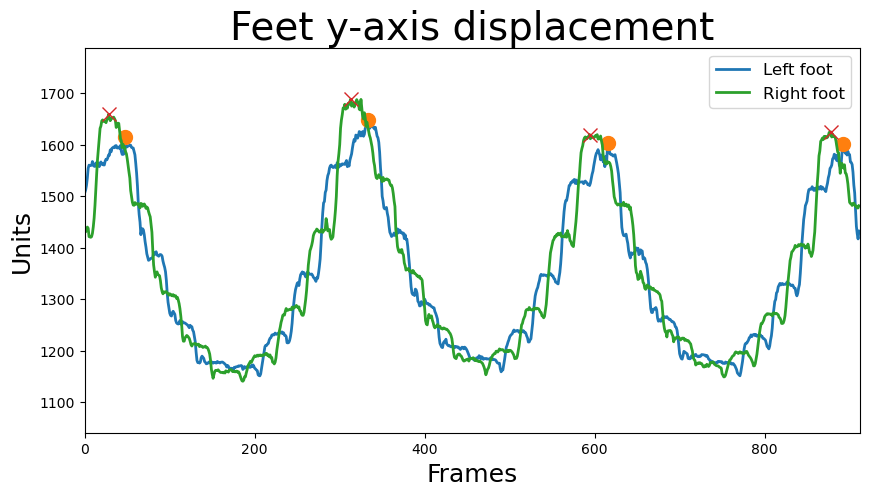

In [12]:
r_leg_x = []
r_leg_y = []
l_leg_x = []
l_leg_y = []
p_rlx = 0
p_rly = 0
p_llx = 0
p_lly = 0

thres = 0.3

delta = lambda x, y, t: y if np.absolute(x - y) > t else x

for i in range(pose_2d.shape[0]):
    if pose_2d[i, 16, -1] > thres:
        r_leg_x.append(pose_2d[i, 16, 0])
        r_leg_y.append(pose_2d[i, 16, 1])
        p_rlx = pose_2d[i, 16, 0]
        p_rly = pose_2d[i, 16, 1]
    else:
        r_leg_x.append(p_rlx)
        r_leg_y.append(p_rly)

    if pose_2d[i, 15, -1] > thres:
        l_leg_x.append(pose_2d[i, 15, 0])
        l_leg_y.append(pose_2d[i, 15, 1])
        p_llx = pose_2d[i, 15, 0]
        p_lly = pose_2d[i, 15, 1]
    else:
        l_leg_x.append(p_llx)
        l_leg_y.append(p_lly)

l_T, l_acf = find_period(moving_average(l_leg_y, 20))
r_T, r_acf = find_period(moving_average(r_leg_y, 20))
l_peaks, _ = find_peaks(l_leg_y, distance=l_T * 0.8)
r_peaks, _ = find_peaks(r_leg_y, distance=r_T * 0.8)

# Set FPS and duration
fps = 30
duration = max(len(r_leg_x), len(l_leg_x)) / fps

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlabel("Frames",  fontsize=18)
ax.set_ylabel("Units",  fontsize=18)
ax.set_title("Feet y-axis displacement",  fontsize=28)
line1, = ax.plot([], [], lw=2,  label = "Left foot")
points1, = ax.plot([], [], "o", ms=10)
line2, = ax.plot([], [], lw=2, label = "Right foot")
points2, = ax.plot([], [], "x", ms=10)
ax.legend( fontsize=12)

# Initialization function
def init():
    ax.set_xlim(0, max(len(r_leg_x), len(l_leg_x)))
    ax.set_ylim(min(min(r_leg_y), min(l_leg_y))-100, max(max(r_leg_y), max(l_leg_y))+100)
    line1.set_data([], [])
    line2.set_data([], [])
    points1.set_data([], [])
    points2.set_data([], [])
    return line1, line2, points1, points2

# Animation function
def animate(i):
    x = np.arange(0, i+1)
    y1 = r_leg_y[:i+1]
    y2 = l_leg_y[:i+1]
    line1.set_data(x, y1)
    line2.set_data(x, y2)
    points1.set_data(r_peaks[r_peaks <= i], np.array(r_leg_y)[r_peaks[r_peaks <= i]])
    points2.set_data(l_peaks[l_peaks <= i], np.array(l_leg_y)[l_peaks[l_peaks <= i]])
    return line1, line2, points1, points2

# Create animation
ani = animation.FuncAnimation(fig, animate, init_func=init, frames=max(len(r_leg_x), len(l_leg_x)), interval=1000/fps, blit=True)

# Save frames
if not os.path.exists("frames"):
    os.mkdir("frames")

for i in range(max(len(r_leg_x), len(l_leg_x))):
    animate(i)
    plt.savefig(f"frames/frame_{i:04d}.png")

# Create a video from the saved frames
with imageio.get_writer('walking_animation.mp4', fps=fps) as writer:
    for i in range(max(len(r_leg_x), len(l_leg_x))):
        image = imageio.imread(f"frames/frame_{i:04d}.png")
        writer.append_data(image)

# Clean up frames directory
shutil.rmtree("frames")

print("Video saved as walking_animation.mp4")


In [7]:
mask_theres = None
pose_3d 
l = 4
r = 1
d_4_1 = []


for i in range(pose_3d.shape[0]):
    d_4_1.append(np.linalg.norm(pose_3d[i, 4, :]- pose_3d[i, 1, :]))


d_4_1 = np.sum(d_4_1, axis=1)

g = np.gradient(moving_average(minmax_scale(d_4_1), 30))
p1 = my_find_peaks_2(-g, 0.015)
p2 = my_find_peaks_2(g, 0.015)

AxisError: axis 1 is out of bounds for array of dimension 1

In [ ]:

def search_next_volley(wave, p, i):
    point = p[i]
    
    while True:
        if point+1 < len(wave):
            if wave[point] >= wave[point+1]:
                point += 1
                continue
            else:
                break
        else:
    return point

def search_before_volley(wave, p, i):
    point = p[i]
    
    while True:
        if wave[point] >= wave[point-1] and point > 0:
            point -= 1
            continue
        else:
            break
    return point
    
g = np.gradient(moving_average(minmax_scale(pose_3d[:, 4, 0]), 30))
p1 = my_find_peaks_2(g, g.min())
plt.plot(g)
plt.plot(p1, g[p1], "x")
plt.show()

new_pt = []
for i in range(len(p1)):
    max = g.max()/2
    min = g.min()/2
    
    if g[p1[i]] > max:
        print(p1[i])
        b = search_before_volley(g, p1, i)
        n = search_next_volley(g, p1, i)
        new_pt.append(b)
        new_pt.append(p1[i])
        new_pt.append(n)
        
plt.plot(g)
plt.plot(new_pt, g[new_pt], "x")
plt.show()     

/tmp/ipykernel_142531/271031021.py:62: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(f"frames/frame_{i:04d}.png")
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1000, 500) to (1008, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved as turning_speed_animation.mp4


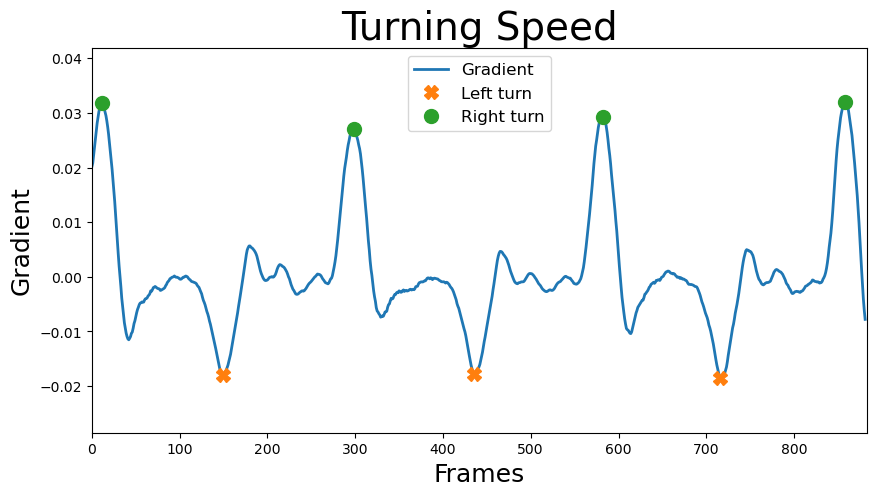

In [10]:
# Set FPS and duration
fps = 30
duration = len(g) / fps

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlabel("Frames",  fontsize=18)
ax.set_ylabel("Gradient",  fontsize=18)
ax.set_title("Turning Speed",  fontsize=28)
line, = ax.plot([], [], lw=2, label="Gradient")
points1, = ax.plot([], [], "X", ms=10, label="Left turn")
points2, = ax.plot([], [], "o", ms=10, label="Right turn")
ax.legend( fontsize=12)

# Initialization function
def init():
    ax.set_xlim(0, len(g))
    ax.set_ylim(min(g)-0.01, max(g)+0.01)
    line.set_data([], [])
    points1.set_data([], [])
    points2.set_data([], [])
    return line, points1, points2

# Animation function
def animate(i):
    x = np.arange(0, i)
    y = g[:i]
    line.set_data(x, y)
    points1.set_data(p1[p1 <= i], g[p1[p1 <= i]])
    points2.set_data(p2[p2 <= i], g[p2[p2 <= i]])
    return line, points1, points2

# Create animation
ani = animation.FuncAnimation(fig, animate, init_func=init, frames=len(g), interval=1000/fps, blit=True)

# Save frames
if not os.path.exists("frames"):
    os.mkdir("frames")

for i in range(len(g)):
    animate(i)
    plt.savefig(f"frames/frame_{i:04d}.png")

# Create a video from the saved frames
with imageio.get_writer('turning_speed_animation.mp4', fps=fps) as writer:
    for i in range(len(g)):
        image = imageio.imread(f"frames/frame_{i:04d}.png")
        writer.append_data(image)

# Clean up frames directory
import shutil
shutil.rmtree("frames")

print("Video saved as turning_speed_animation.mp4")


In [4]:
pose_3d.shape

(912, 17, 3)

In [ ]:
d_4_1.append(pose_3d[i, l, :] - pose_3d[i, r, :])


NameError: name 'i' is not defined